In [1]:
import torch
import torch.nn as nn
import torch.autograd.functional as F

# ---- Tiny Neural Net ----
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 3)   # input=2 → hidden=3
        self.fc2 = nn.Linear(3, 2)   # hidden=3 → output=2

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize net
net = TinyNet()

# Dummy input
x = torch.tensor([[1.0, 2.0]], requires_grad=True)

# Forward pass
y = net(x)

print("Output y:\n", y)
print("Weights of fc1:\n", net.fc1.weight)
print("Weights of fc2:\n", net.fc2.weight)


Output y:
 tensor([[1.2536, 0.6597]], grad_fn=<AddmmBackward0>)
Weights of fc1:
 Parameter containing:
tensor([[-0.0725,  0.0930],
        [-0.1067, -0.4269],
        [ 0.7002,  0.5406]], requires_grad=True)
Weights of fc2:
 Parameter containing:
tensor([[ 0.3832,  0.4316,  0.5132],
        [-0.0271, -0.3524,  0.5147]], requires_grad=True)


In [2]:
import torch
import torch.nn.functional as F

# Use your existing net and x
# net = TinyNet(); x = torch.tensor([[1.0, 2.0]], requires_grad=True)

# 1) Forward with explicit intermediates
x_col = x.t()                               # (2,1)
W1 = net.fc1.weight.detach().clone()        # (3,2)
b1 = net.fc1.bias.detach().clone()          # (3,)
W2 = net.fc2.weight.detach().clone()        # (2,3)
b2 = net.fc2.bias.detach().clone()          # (2,)

z1 = (W1 @ x_col).squeeze(-1) + b1          # (3,)
a1 = torch.relu(z1)                         # (3,)
z2 = (W2 @ a1) + b2                         # (2,)
y  = z2

# 2) Loss and autograd grads
L = y.sum()
net.zero_grad(set_to_none=True)
L.backward()

print("z1:", z1.tolist())
mask = (z1 > 0).float()
print("ReLU mask D:", mask.tolist())

# 3) Our manual grads using VJPs
g_y = torch.ones_like(y)                    # (2,)
g_a1 = W2.t() @ g_y                         # (3,)
g_z1 = mask * g_a1                          # (3,)
grad_W1_manual = g_z1.view(-1,1) @ x_col.t()# (3,2)
grad_b1_manual = g_z1                       # (3,)
grad_W2_manual = g_y.view(-1,1) @ a1.view(1,-1)  # (2,3)
grad_b2_manual = g_y                        # (2,)
g_x_manual = W1.t() @ g_z1                  # (2,)

# 4) Compare to autograd
print("\n=== Compare to autograd ===")
print("∂L/∂W1 (manual):\n", grad_W1_manual)
print("∂L/∂W1 (autograd):\n", net.fc1.weight.grad)
print("∂L/∂b1 (manual):\n", grad_b1_manual)
print("∂L/∂b1 (autograd):\n", net.fc1.bias.grad)
print("∂L/∂W2 (manual):\n", grad_W2_manual)
print("∂L/∂W2 (autograd):\n", net.fc2.weight.grad)
print("∂L/∂b2 (manual):\n", grad_b2_manual)
print("∂L/∂b2 (autograd):\n", net.fc2.bias.grad)
print("∂L/∂x  (manual):\n", g_x_manual.view(1,-1))
print("∂L/∂x  (autograd):\n", x.grad)


z1: [0.6110337972640991, -0.32599514722824097, 2.2450525760650635]
ReLU mask D: [1.0, 0.0, 1.0]

=== Compare to autograd ===
∂L/∂W1 (manual):
 tensor([[0.3561, 0.7122],
        [0.0000, 0.0000],
        [1.0280, 2.0559]], grad_fn=<MmBackward0>)
∂L/∂W1 (autograd):
 None
∂L/∂b1 (manual):
 tensor([0.3561, 0.0000, 1.0280])
∂L/∂b1 (autograd):
 None
∂L/∂W2 (manual):
 tensor([[0.6110, 0.0000, 2.2451],
        [0.6110, 0.0000, 2.2451]], grad_fn=<MmBackward0>)
∂L/∂W2 (autograd):
 None
∂L/∂b2 (manual):
 tensor([1., 1.])
∂L/∂b2 (autograd):
 None
∂L/∂x  (manual):
 tensor([[0.6939, 0.5888]])
∂L/∂x  (autograd):
 tensor([[0.6939, 0.5888]])


/media/guru/e3dd0686-a58b-467b-913b-60b095056804/Deep_Gen_AI/lib/python3.10/site-packages/torch/autograd/graph.py:829: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Output y: [[0.95770764 0.91381073]]

Jacobian dy/dx:
 [[0.33156064 0.31307352]
 [0.3623577  0.27572653]]

Hessian d^2L/dx^2:
 [[0. 0.]
 [0. 0.]]


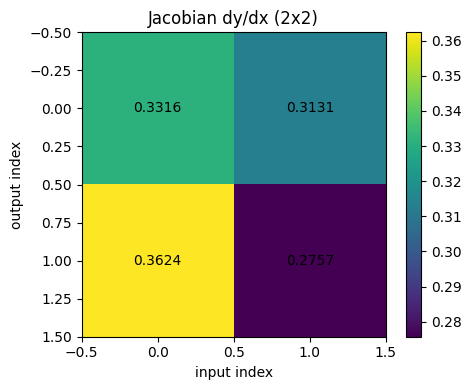

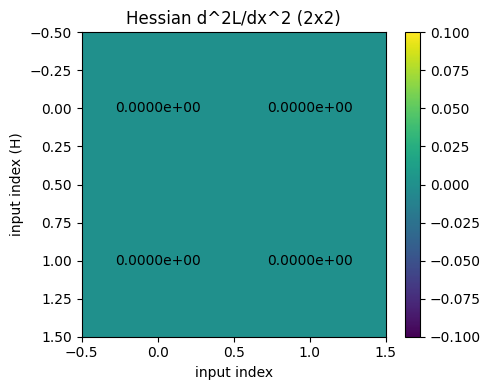

In [3]:
# Recreate the TinyNet with the exact weights you printed (biases unknown → set to 0)
# Compute and plot:
#  - Jacobian J = dy/dx (shape 2x2)
#  - Hessian H = d^2L/dx^2 for L = sum(y) (shape 2x2)
# Then show both matrices as separate matplotlib plots (each its own figure).
import torch
import torch.nn as nn
import torch.autograd.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Recreate net structure
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 3, bias=True)
        self.fc2 = nn.Linear(3, 2, bias=True)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

net = TinyNet()

# Use the exact weights you printed earlier
W1 = torch.tensor([[-0.0725,  0.0930],
                   [-0.1067, -0.4269],
                   [ 0.7002,  0.5406]], dtype=torch.float32)
W2 = torch.tensor([[ 0.3832,  0.4316,  0.5132],
                   [-0.0271, -0.3524,  0.5147]], dtype=torch.float32)

with torch.no_grad():
    net.fc1.weight.copy_(W1)
    net.fc2.weight.copy_(W2)
    # biases were not provided in your printout — set to zero (explicitly)
    net.fc1.bias.zero_()
    net.fc2.bias.zero_()

# Input (as you had)
x = torch.tensor([[1.0, 2.0]], requires_grad=True)  # shape (1,2)

# Forward to check outputs
y = net(x)
print("Output y:", y.detach().numpy())

# Define scalar loss L = sum(y)
def loss_fn(inp):
    out = net(inp)
    return out.sum()

# Compute Jacobian dy/dx (we want dy (2,) wrt x (2,))
# autograd.functional.jacobian expects function returning tensor; we'll compute per-sample
J = F.jacobian(lambda inp: net(inp).squeeze(0), x.squeeze(0))  # shape (2,2)
J = J.detach().cpu().numpy()

# Compute Hessian of loss wrt input x (since L is scalar)
H = F.hessian(lambda inp: loss_fn(inp.unsqueeze(0)), x.squeeze(0))  # shape (2,2)
H = H.detach().cpu().numpy()

# Print matrices
print("\nJacobian dy/dx:\n", J)
print("\nHessian d^2L/dx^2:\n", H)

# Plot Jacobian and Hessian as separate figures
plt.figure(figsize=(5,4))
plt.title("Jacobian dy/dx (2x2)")
plt.imshow(J, aspect='equal')
plt.colorbar()
for (i, j), val in np.ndenumerate(J):
    plt.text(j, i, f"{val:.4f}", ha='center', va='center')
plt.xlabel("input index")
plt.ylabel("output index")
plt.tight_layout()

plt.figure(figsize=(5,4))
plt.title("Hessian d^2L/dx^2 (2x2)")
plt.imshow(H, aspect='equal')
plt.colorbar()
for (i, j), val in np.ndenumerate(H):
    plt.text(j, i, f"{val:.4e}", ha='center', va='center')
plt.xlabel("input index")
plt.ylabel("input index (H)")
plt.tight_layout()

plt.show()
